In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning Notebook 1: Introduction
This notebook serves to show how to implement a simple neural network model from scratch, and how to train and evaluate it. Only Numpy is used.

# The dataset (MNIST)

In this first step, we load and visualize the data set. We also have to preprocess it a bit.

### Loading the data

First, we load the data from the provided .csv-files. The csv-files consist of one row per datapoint, the first entry being the target class (i.e. the digit) and the 784 (which equals 28x28) other entries being the (row-wise linearized) grayscale pixels of the respective image (values between 0 and 255).

In [2]:
import csv

# Train data
with open("mnist_train_small.csv", newline='\n') as csvfile:
  csvfile = csv.reader(csvfile, delimiter=',')
  data = np.array([r for r in csvfile])
  data_train_x = data[:,1:].astype('float') # skip first column
  data_train_y = data[:,0].astype('int') # first column only


# Test data
with open("mnist_test.csv", newline='\n') as csvfile:
  csvfile = csv.reader(csvfile, delimiter=',')
  data = np.array([r for r in csvfile])
  data_test_x = data[:,1:].astype('float')
  data_test_y = data[:,0].astype('int')

### Inspecting the data

Now, we can inspect our data and check its shapes.

data_train_x.shape: (20000, 784)
data_train_y.shape: (20000,)
data_test_x.shape: (10000, 784)
data_test_y.shape: (10000,)


Label of the first test set entry: 7


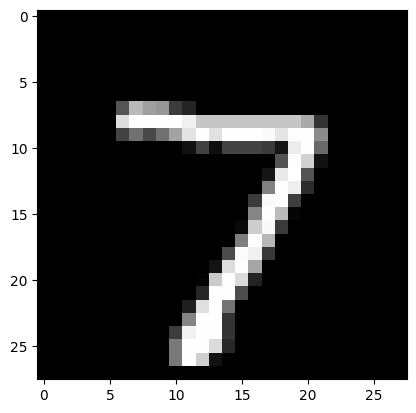

In [3]:
# Shape of the datasets:
print("data_train_x.shape:",data_train_x.shape)
print("data_train_y.shape:",data_train_y.shape)
print("data_test_x.shape:",data_test_x.shape)
print("data_test_y.shape:",data_test_y.shape)
print("\n")


# Inspecting the first entry of the test dataset:
x0 = data_test_x[0]
y0 = data_test_y[0]
print("Label of the first test set entry:",y0)

x0_reshaped = x0.reshape((28,28)) # Reshape the vector to a 28x28 matrix
plt.imshow(x0_reshaped, cmap='gray') # cmap='gray' makes the image grayscale
plt.show()

### Preprocessing the data

For preprocessing, we divide each grayscale value by 255 and standardize the dataset.

In [4]:
data_train_x /= 255
data_test_x /= 255

mean = np.mean(data_train_x)
std = np.std(data_train_x)

print("Mean:",mean,"Std:",std)

# standardization
data_train_x = (data_train_x-mean)/std
data_test_x = (data_test_x-mean)/std

Mean: 0.13130349323062576 Std: 0.3089881020118576


In another pre-processing step, we transform the target labels into one-hot encodings. <br>
We do this by constructing an identity matrix of shape(10,10) using np.eye(10). Then we index this matrix by the array data_train_y. This selects, for each entry in the array, the appropriate row from np.eye(10). The final result is a new array with shape (len(data_train_y), 10).

In [5]:
data_train_y_one_hot = np.eye(10)[data_train_y]
data_test_y_one_hot = np.eye(10)[data_test_y]

### The easiest parts first!

To start off, lets implement sigmoid and softmax, as well as their respective derivatives. We can later pass an array to these functions and will get back an array of the same shape.

In [6]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def softmax(x):
    exps = np.exp(x - x.max())
    return exps / (np.sum(exps, axis=0))

def sigmoid_derivative(x):
    return (np.exp(-x))/((np.exp(-x)+1)**2)

def softmax_derivative(x):
    exps = np.exp(x - x.max())
    return exps / np.sum(exps, axis=0) * (1 - exps / np.sum(exps, axis=0))

#### Beginning the model class

Now we should begin writing the model class. We will do this step by step and add the functions as we go, with explanations in-between.

In [7]:
class FFN(): # Feed Forward Network
  def __init__(self, sizes=[784, 128, 64, 10], epochs=10, l_rate=0.001):
    self.sizes = sizes
    self.epochs = epochs
    self.l_rate = l_rate

    self.params = self.initialize_parameters()

### Setting up the network: Initialization

We must guarantee that the initial parameters (the weights) have some variation in them. Otherwise, the model could not begin with the training. For more details, see [this blog post.](https://machinelearning.uni-saarland.de/wp-content/uploads/2024/07/breakingthesymmetry.pdf). It also explains the specific form of initialization we are using, called Xavier initialization.

In [8]:
def initialize_parameters(self):
  input_layer=self.sizes[0]
  hidden_1=self.sizes[1]
  hidden_2=self.sizes[2]
  output_layer=self.sizes[3]

  params = { # Xavier initialization (fan-in/fan-out method)
      'W1': np.random.randn(hidden_1, input_layer) * np.sqrt(2. / (hidden_1 + input_layer)),
      'W2': np.random.randn(hidden_2, hidden_1) * np.sqrt(2. / (hidden_2 + hidden_1)),
      'W3': np.random.randn(output_layer, hidden_2) * np.sqrt(2. / (output_layer + hidden_2))
  }

  print("Initialized! Total parameters:", np.prod(params['W1'].shape)+np.prod(params['W2'].shape)+np.prod(params['W3'].shape))

  return params

FFN.initialize_parameters = initialize_parameters # add the function to the class


### Implementing the forward pass:

Now, we have everything we need to implement a forward pass.
We store the activations for later usage during backpropagation.

In [9]:
def forward(self, x_train):
  params = self.params

  # the first activations should just be the input sample
  params['A0'] = x_train

  # input layer to hidden layer 1
  params['Z1'] = np.dot(params["W1"], params['A0'])
  params['A1'] = sigmoid(params['Z1'])

  # hidden layer 1 to hidden layer 2
  params['Z2'] = np.dot(params["W2"], params['A1'])
  params['A2'] = sigmoid(params['Z2'])

  # hidden layer 2 to output layer
  params['Z3'] = np.dot(params["W3"], params['A2'])
  params['A3'] = softmax(params['Z3'])

  return params['A3']

FFN.forward=forward


### Evaluating the model:

We can now also write some code to evaluate the accuracy of our model on some data:

In [10]:
def accuracy(self, data_x, data_y):
    prediction_matches_label = []

    for x, y in zip(data_x, data_y):
        output = self.forward(x)
        pred = np.argmax(output)
        prediction_matches_label.append(pred == y) # Appends boolean values, i.e. True if prediction matches label, False otherwise
    return np.mean(prediction_matches_label) # np.mean() converts the boolean values to 0 and 1

FFN.accuracy=accuracy

### Sanity check: performance of a random network

To test the code that we have so far, we can initialize our model with random weights, and compute the accuracy on the MNIST training dataset. Since we haven't trained the model, we should expect an accuracy of somewhere around 10%, since there are 10 classes in our dataset. The concrete value depends on the initialization, which is random.

In [11]:
model = FFN()
accuracy = model.accuracy(data_train_x, data_train_y)
print("Accuracy = {:.2f}%".format(accuracy*100))

Initialized! Total parameters: 109184
Accuracy = 9.87%


### Backpropagation

Next, we should implement the function that allows us to compute the gradients of the loss w.r.t. the weights.

A useful info to keep in mind is that the shape of the changes needs to be the same as the shape of the respective parameters. Mostly, there is only one order for the outer product that gives a correctly shaped gradient.

In [12]:
def backward(self, data_y, predictions):
    params = self.params
    change_w = {}

    # Calculate W3 update
    error = 2 * (predictions - data_y) * softmax_derivative(params['Z3']) # The first part is the derivative of the squared loss
    change_w['W3'] = np.outer(error, params['A2'])

    # Calculate W2 update
    error = np.dot(params['W3'].T, error) * sigmoid_derivative(params['Z2'])
    change_w['W2'] = np.outer(error, params['A1'])

    # Calculate W1 update
    error = np.dot(params['W2'].T, error) * sigmoid_derivative(params['Z1'])
    change_w['W1'] = np.outer(error, params['A0'])

    return change_w

FFN.backward = backward


In [13]:
def update_network_parameters(self, changes_to_w):
  for key, value in changes_to_w.items():
    self.params[key] -= self.l_rate * value # Update each parameter by taking a step in the opposite direction of the gradient
    
FFN.update_network_parameters = update_network_parameters

### Training loop

Finally, we can tie everything together by writing a training loop:



In [14]:
def train(self, data_x, data_y):
  train_accs = []

  for epoch in range(self.epochs):
      accuracy = self.accuracy(data_x, np.argmax(data_y,axis=1)) # the argmax is needed to undo the one-hot encoding
      train_accs.append(accuracy)
      print('Epoch: {:d}, Train accuracy = {:.2f}%'.format( epoch, accuracy*100))

      for x,y in zip(data_x, data_y):
          output = self.forward(x)
          changes_to_w = self.backward(y, output)
          self.update_network_parameters(changes_to_w)
      
  return train_accs
FFN.train = train

### Executing the training:

Lets initialize a model and train it for a bit, before evaluating its accuracy on the test-set.


In [15]:
model = FFN(epochs=10, l_rate=0.01)
model.train(data_train_x, data_train_y_one_hot)

print()
accuracy = model.accuracy(data_test_x, data_test_y)
print("Test accuracy = {:.2f}%".format(accuracy*100))

Initialized! Total parameters: 109184
Epoch: 0, Train accuracy = 13.10%
Epoch: 1, Train accuracy = 84.19%
Epoch: 2, Train accuracy = 89.76%
Epoch: 3, Train accuracy = 92.40%
Epoch: 4, Train accuracy = 93.62%
Epoch: 5, Train accuracy = 94.41%
Epoch: 6, Train accuracy = 94.64%
Epoch: 7, Train accuracy = 94.28%
Epoch: 8, Train accuracy = 94.42%
Epoch: 9, Train accuracy = 94.53%

Test accuracy = 92.71%


# Doing the same in PyTorch

In [16]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [17]:
train_dataset = datasets.MNIST(root='./data', 
                            train=True, 
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = datasets.MNIST(root='./data', 
                           train=False, 
                           transform=transforms.ToTensor())

In [18]:
class TorchFFN(nn.Module):
    def __init__(self,sizes=[784, 128, 64, 10]):
        super().__init__()

        fc1 = nn.Linear(sizes[0],sizes[1])
        fc2 = nn.Linear(sizes[1],sizes[2])
        fc3 = nn.Linear(sizes[2],sizes[3])
        self.layers = nn.Sequential(
                        fc1,
                        nn.Sigmoid(),
                        fc2,
                        nn.Sigmoid(),
                        fc3
                        #nn.Softmax() is computed implicitly in the loss
        )

    def forward(self, input):
      return self.layers(input)


In [19]:
model = TorchFFN()
epochs, lr = 10, 0.01
opt = torch.optim.SGD(model.parameters(), lr=lr)
objective = nn.CrossEntropyLoss()

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=16, # We only used batches of size 1 earlier
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=16, 
                                          shuffle=False)

In [20]:
# Training

for epoch in range(epochs):
    correct = 0
    count = 0
    for i,(x, y) in enumerate(train_loader):
        x = x.reshape(x.shape[0],-1) # flattens the batch of images from shape (16,28,28) to (16,784)
        
        outputs = model(x) # shape of outputs is (16,10)
        _ , predicted = torch.max(outputs.data, dim=1) # the second return value is the index of the max value of each row (dim=1), i.e. the argmax, i.e. the predicted class

        count += y.size(0) # y.size(0) is the number of elements in y, i.e. the batch size (except for one batch at the end of the dataset, which might be smaller)
        correct += (predicted == y).sum() # Adds the number of correct predictions in the batch

    acc = correct/count
    print("Epoch: %d, Train accuracy: %.2f" % (epoch, acc*100))

    for i,(x, y) in enumerate(train_loader):
        x = x.reshape(x.shape[0],-1)
        opt.zero_grad() # Clears the gradients from previous iteration
        output = model(x)
        loss = objective(output,y)
        loss.backward() # Does the backward pass and computes all gradients
        opt.step() # Updates the weights accordingly


# Evaluation on test set

correct = 0
count = 0
for i,(x, y) in enumerate(test_loader):
    x = x.reshape(x.shape[0],-1)
    outputs = model(x)
    _ , predicted = torch.max(outputs.data, dim=1) # argmax across rows
    count += y.size(0)
    correct += (predicted == y).sum()

acc = correct/count
print("Test accuracy = %.2f" % (acc*100))

Epoch: 0, Train accuracy: 10.44
Epoch: 1, Train accuracy: 10.60
Epoch: 2, Train accuracy: 50.65
Epoch: 3, Train accuracy: 70.38
Epoch: 4, Train accuracy: 80.15
Epoch: 5, Train accuracy: 84.31
Epoch: 6, Train accuracy: 86.73
Epoch: 7, Train accuracy: 88.12
Epoch: 8, Train accuracy: 88.99
Epoch: 9, Train accuracy: 89.64
Test accuracy = 90.52


# References and Sources

*   https://mlfromscratch.com/neural-network-tutorial/#/
*   https://deepnotes.io/softmax-crossentropy
*   https://cs231n.github.io/optimization-2/#grad
*   https://www.kdnuggets.com/2019/08/numpy-neural-networks-computational-graphs.html
* https://pytorch.org/docs/stable/index.html
